In [21]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

import sys
sys.path.append('../../')

import superstats as sup
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from scipy.stats import median_abs_deviation

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = ['Palatino', 'Palatino Linotype', 'DejaVu Serif']

import jax
print(jax.devices())

[CpuDevice(id=0)]


## Constants

In [22]:
NUM_STEPS = 800
NUM_SAMPLES = 500
NUM_EPOCHS = 100
NUM_ITER_PER_EPOCH = 1000
BATCH_SIZE = 32

## Prior

In [3]:
joint_prior = sup.prior.JointPrior(
    v = sup.transition.Mixture(
        transitions=[
            sup.transition.RandomWalk(
                sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
                delta=0
            ),
            sup.transition.Jump(
                proposal_prior=sup.prior.Prior(dist="logistic", loc=0, scale=1)
            )
        ],
        mixture_weights=sup.prior.Prior(dist="dirichlet", alpha=[20.0, 1.5]),
        bounds=(0.0, 8.0),
        initial_prior=sup.prior.Prior(dist="normal", loc=-1.0, scale=1.0),
    ),
    a = sup.transition.Mixture(
        transitions=[
            sup.transition.RandomWalk(
                sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
                delta=0
            ),
            sup.transition.Jump(
                proposal_prior=sup.prior.Prior(dist="logistic", loc=0, scale=1)
            )
        ],
        mixture_weights=sup.prior.Prior(dist="dirichlet", alpha=[40.0, 1.5]),
        bounds=(0.0, 6.0),
        initial_prior=sup.prior.Prior(dist="normal", loc=-0.5, scale=1.0),
    ),
    tau = sup.transition.RandomWalk(
        sigma=sup.prior.Prior(dist="halfnormal", scale=0.01),
        delta=0,
        bounds=(0.0, 4.0),
        initial_prior=sup.prior.Prior(dist="normal", loc=-1.0, scale=1.0)
    ),
    bias = 0.5
)

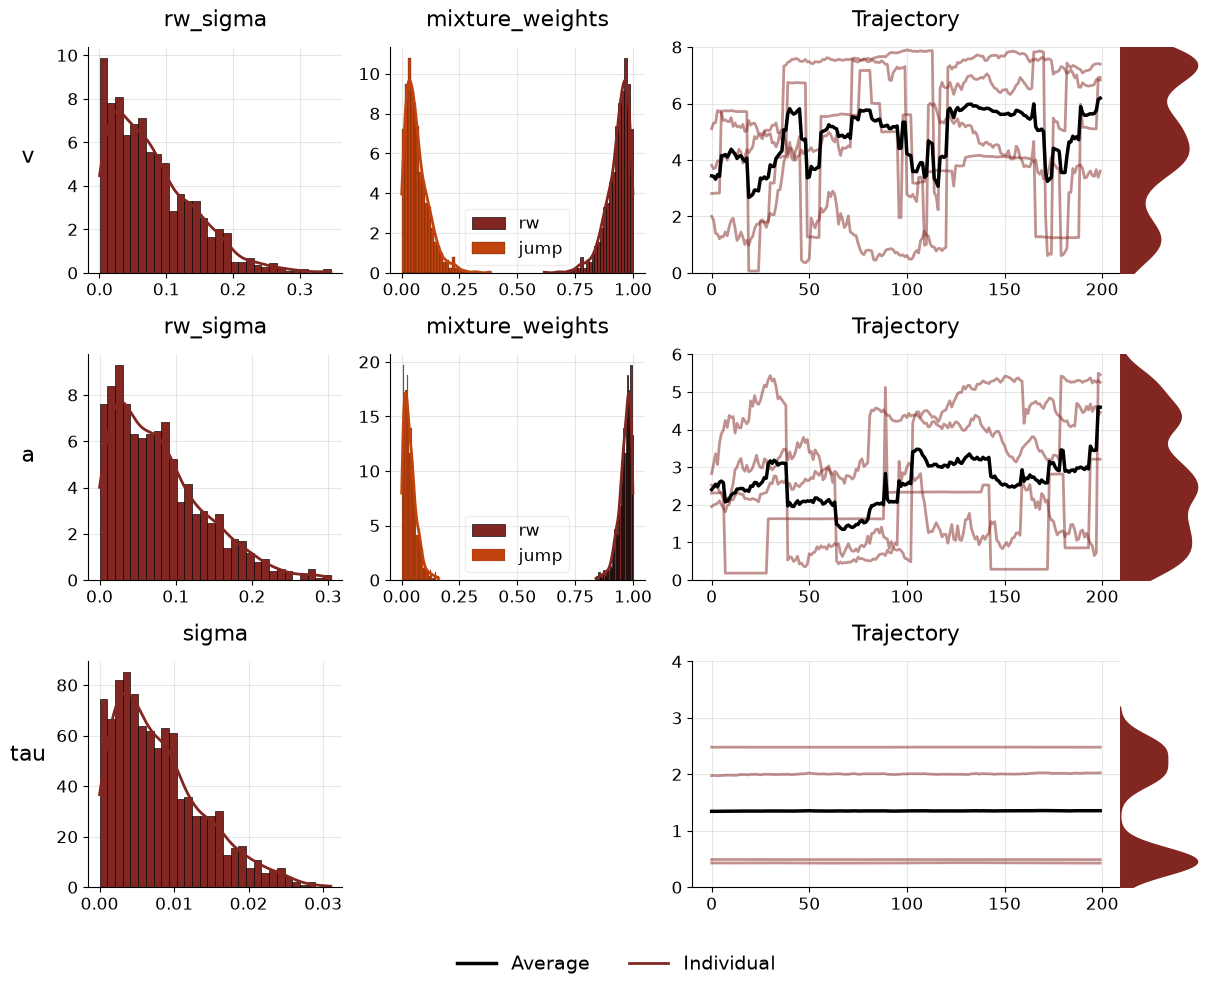

In [4]:
fig = joint_prior.plot_joint_prior(num_trajectories=4)

## Generative Model

In [5]:
ddm = sup.simulation.sample_ddm

generative_model = sup.simulation.GenerativeModel(
    prior=joint_prior,
    model=ddm,
)

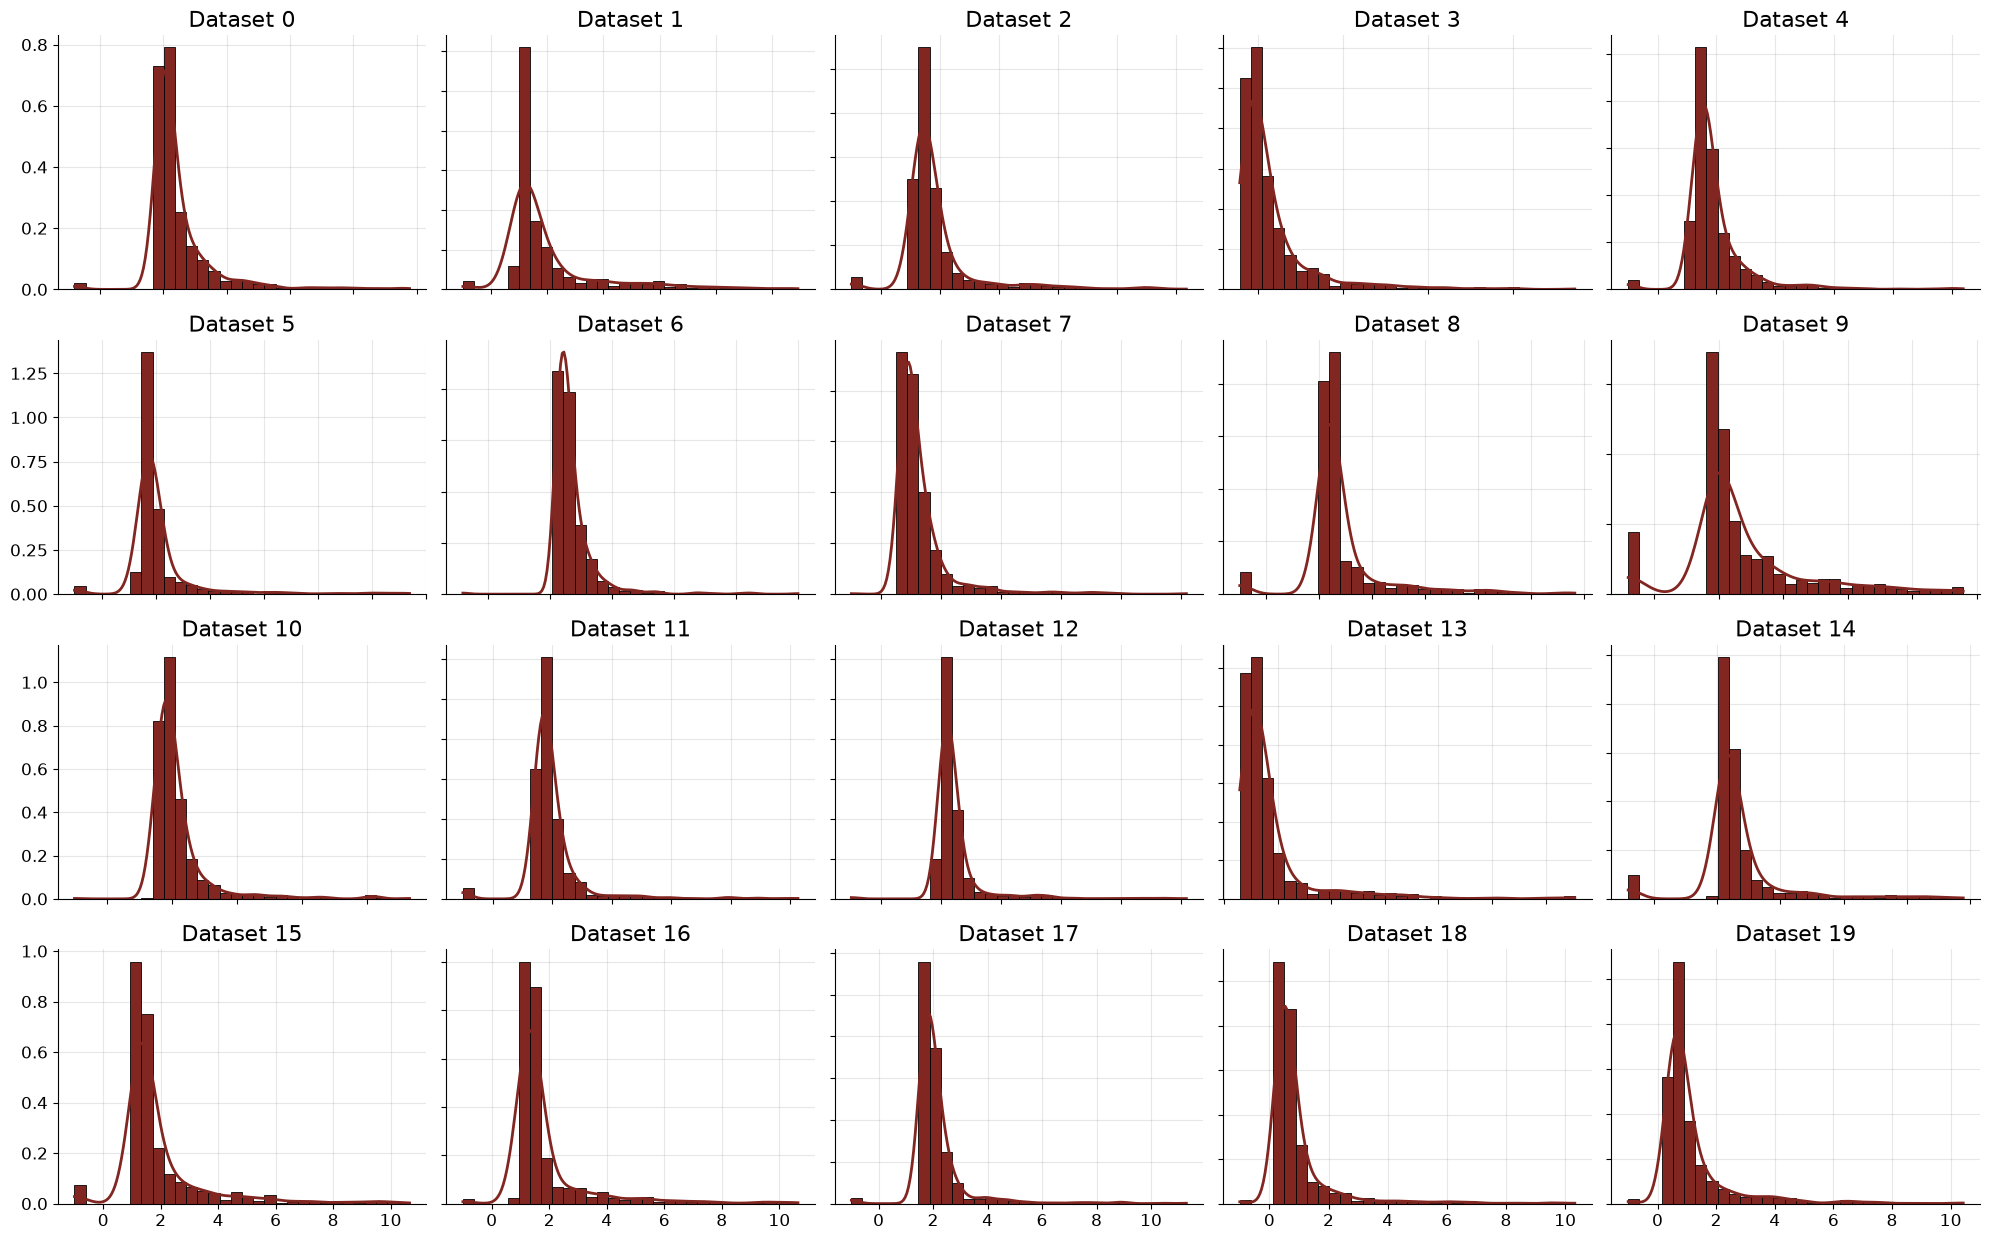

In [6]:
fig = generative_model.plot_push_forward(
    num_sim=20,
    num_steps=NUM_STEPS,
    data_dim=0,
    kind="dist",
    num_cols=5,
)

## Workflow

In [7]:
workflow = sup.workflow.Workflow(
    simulator=generative_model,
    checkpoint_filepath="checkpoint_app_01"
)

Existing checkpoints are not automatically loaded. Upon refitting, the checkpoints will be overwritten.
To restore the approximator from the checkpoint, call workflow.load_approximator() or pass restore=True to the workflow constructor.
INFO:bayesflow:Approximator restored from 'checkpoint_app_01/model.keras'.


## Training

In [ ]:
history = workflow.fit_online(
    num_steps=NUM_STEPS,
    epochs=NUM_EPOCHS,
    num_batches_per_epoch=NUM_ITER_PER_EPOCH,
    batch_size=BATCH_SIZE
)

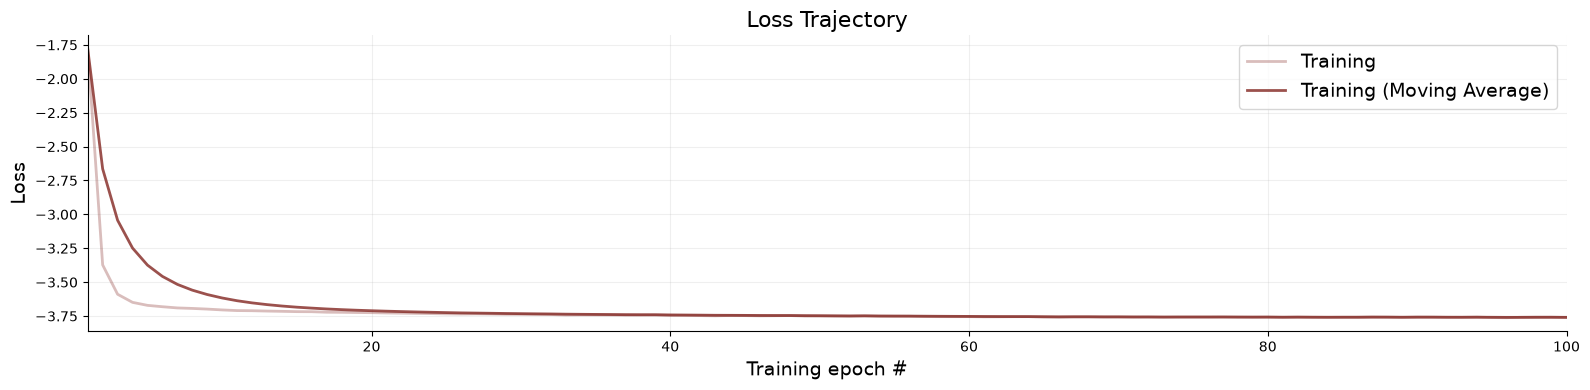

In [8]:
fig = workflow.plot_history(workflow.history)

## Verification

In [ ]:
val_data = workflow.simulator.sample(
    batch_size=400,
    num_steps=NUM_STEPS
)

In [ ]:
samples = workflow.sample(
    data=val_data['data'],
    num_samples=NUM_SAMPLES,
    inference_batch_size=1
)

### Time-varying Parameters

In [ ]:
fig = workflow.verify_time_varying(val_data, samples)

### Time-invariant Parameters

In [ ]:
fig_recovery, fig_calibration = workflow.verify_time_invariant(
    val_data,
    samples
)

## Data Fitting

In [9]:
data = pd.read_csv("data/data_color_discrimination.csv")
data

,id,age,sex,tutorial,speed_condition,difficulty,rt,resp,correct_response,correct
0,1,23,1,0,1,1,0.801806,a,l,0
1,1,23,1,0,1,1,0.639257,a,a,1
2,1,23,1,0,1,1,0.373820,l,a,0
3,1,23,1,0,1,1,0.517185,l,a,0
4,1,23,1,0,1,1,0.834339,a,a,1
...,...,...,...,...,...,...,...,...,...,...
10747,14,23,1,0,1,2,0.592354,l,l,1
10748,14,23,1,0,1,2,0.481805,l,l,1
10749,14,23,1,0,1,2,0.549879,a,a,1
10750,14,23,1,0,1,2,0.533534,a,a,1


In [10]:
def df_to_array(df, cols, id_col="id"):
    """Convert a long-format df into a (num_id, num_steps, num_cols) array.

    Parameters
    ----------
    df     : pd.DataFrame
        Long-format data with one row per id per step/trial.
    cols   : list of str
        Column names to stack into the last dimension, in order.
    id_col : str, optional, default: "id"
        Column identifying each unit (subject/id).

    Returns
    -------
    out : np.ndarray of shape (num_id, num_steps, len(cols))
    """
    ids = df[id_col].unique()
    num_id = len(ids)

    counts = df.groupby(id_col).size()
    num_steps = counts.iloc[0]
    if not (counts == num_steps).all():
        raise ValueError(
            f"Not all ids have the same number of trials: {counts.unique()}"
        )

    num_cols = len(cols)
    out = np.empty((num_id, num_steps, num_cols), dtype=float)

    for i, id_ in enumerate(ids):
        sub = df[df[id_col] == id_]
        out[i] = sub[cols].to_numpy()

    return out

In [11]:
emp_data = df_to_array(data, cols=["rt", "correct"], id_col="id")
context_data = df_to_array(data, cols=["speed_condition", "difficulty"], id_col="id")
print(emp_data.shape)

(14, 768, 2)


In [12]:
samples = workflow.sample(
    data=emp_data,
    num_samples=NUM_SAMPLES,
    inference_batch_size=2
)

Summarizing:   0%|          | 0/7 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/7 [00:00<?, ?batch/s]

In [13]:
local_keys = workflow.simulator.local_keys

stacked = []
for name in local_keys:
    arr = samples[name][..., 0]

    med = np.median(arr, axis=1)
    mad = median_abs_deviation(arr, axis=1, scale=1.0)

    lower = med - mad
    upper = med + mad

    stacked.append(np.stack([lower, med, upper], axis=-1))

post_summaries = np.stack(stacked, axis=2)
print(post_summaries.shape)

(14, 768, 3, 3)


In [23]:
FONT_SIZE_1 = 24
FONT_SIZE_2 = 20
FONT_SIZE_3 = 18
COLOR = "#822621"

LOCAL_PARAM_LABELS = [
    "Drift rate",
    "Boundary separation",
    "Non-decision time",
]

LOCAL_PARAM_NAMES = [
    r"$v$", r"$a$",r"$\tau$",
]

In [ ]:
def plot_parameter_trajectory(
    post_summaries,
    context_data,
    dataset_idx,
    lw=2
):
    NUM_OBS = post_summaries.shape[1]
    num_params = post_summaries.shape[2]

    condition = context_data[dataset_idx, :, 0]
    difficulty = context_data[dataset_idx, :, 1]

    idx_speed = []
    if condition[0] == 1:
        idx_speed.append([0])
        idx_speed.append(np.where(condition[:-1] != condition[1:])[0])
        idx_speed = np.concatenate(idx_speed)
    else:
        idx_speed.append(np.where(condition[:-1] != condition[1:])[0])
        idx_speed.append([NUM_OBS])
        idx_speed = np.concatenate(idx_speed)

    post_lower  = post_summaries[dataset_idx, :, :, 0]
    post_median = post_summaries[dataset_idx, :, :, 1]
    post_upper  = post_summaries[dataset_idx, :, :, 2]

    fig, axarr = plt.subplots(num_params, 1, figsize=(18, 14))
    for i, ax in enumerate(axarr.flat):
        ax.plot(
            range(NUM_OBS),
            post_median[:, i],
            color=COLOR, alpha=0.9, lw=lw, label="Posterior median"
            )
        ax.fill_between(
            range(NUM_OBS),
            post_lower[:, i],
            post_upper[:, i],
            color=COLOR, alpha=0.5, label="Posterior MAD", linewidth=0.0
            )
        # yellow shades
        x = 0
        while x < idx_speed.shape[0]:
            ax.axvspan(idx_speed[x] + 1, idx_speed[x + 1] + 1, alpha=0.2, color='#f0c654', label="Speed condition")
            x = x + 2
        # difficulty manipulation
        if i == 0:
            ax.plot(
                range(NUM_OBS),
                (difficulty - 3) * -2,
                color='black', alpha=0.5, lw=lw, label="Difficulty manipulation"
            )
        # aesthetics
        ax.set_title(
            f'{LOCAL_PARAM_LABELS[i]} ({LOCAL_PARAM_NAMES[i]})',
            fontsize=FONT_SIZE_1,
            pad=20
        )
        ax.grid(alpha=0.3)
        time = np.arange(0, NUM_OBS+1, 48)
        time[0] = 1
        ax.set_xticks(time)
        ax.margins(x=0.01)
        ax.tick_params(axis='both', which='major', labelsize=FONT_SIZE_3)
        ax.set_ylabel("Parameter value", labelpad=20, fontsize=FONT_SIZE_2)
        if i == num_params - 1:
            ax.set_xlabel("Trial", labelpad=20, fontsize=FONT_SIZE_2)
    sns.despine()
    fig.subplots_adjust(hspace=0.4)

    # legend
    handles = [
        Line2D(xdata=[], ydata=[], color=COLOR, alpha=0.8, lw=3, label="Posterior median"),
        Patch(facecolor=COLOR, alpha=0.5, edgecolor=None, label="Posterior MAD"),
        Patch(facecolor='#f0c654', alpha=0.2, edgecolor=None, label="Speed condition"),
        Line2D(xdata=[], ydata=[], color='black', alpha=0.5, lw=3, label="Difficulty condition")
        ]
    fig.legend(
        handles,
        ["Posterior median", "Posterior MAD", "Speed condition", "Difficulty condition"],
        fontsize=FONT_SIZE_2, bbox_to_anchor=(0.5, -0.001),
        loc="center", ncol=4
        )
    return fig

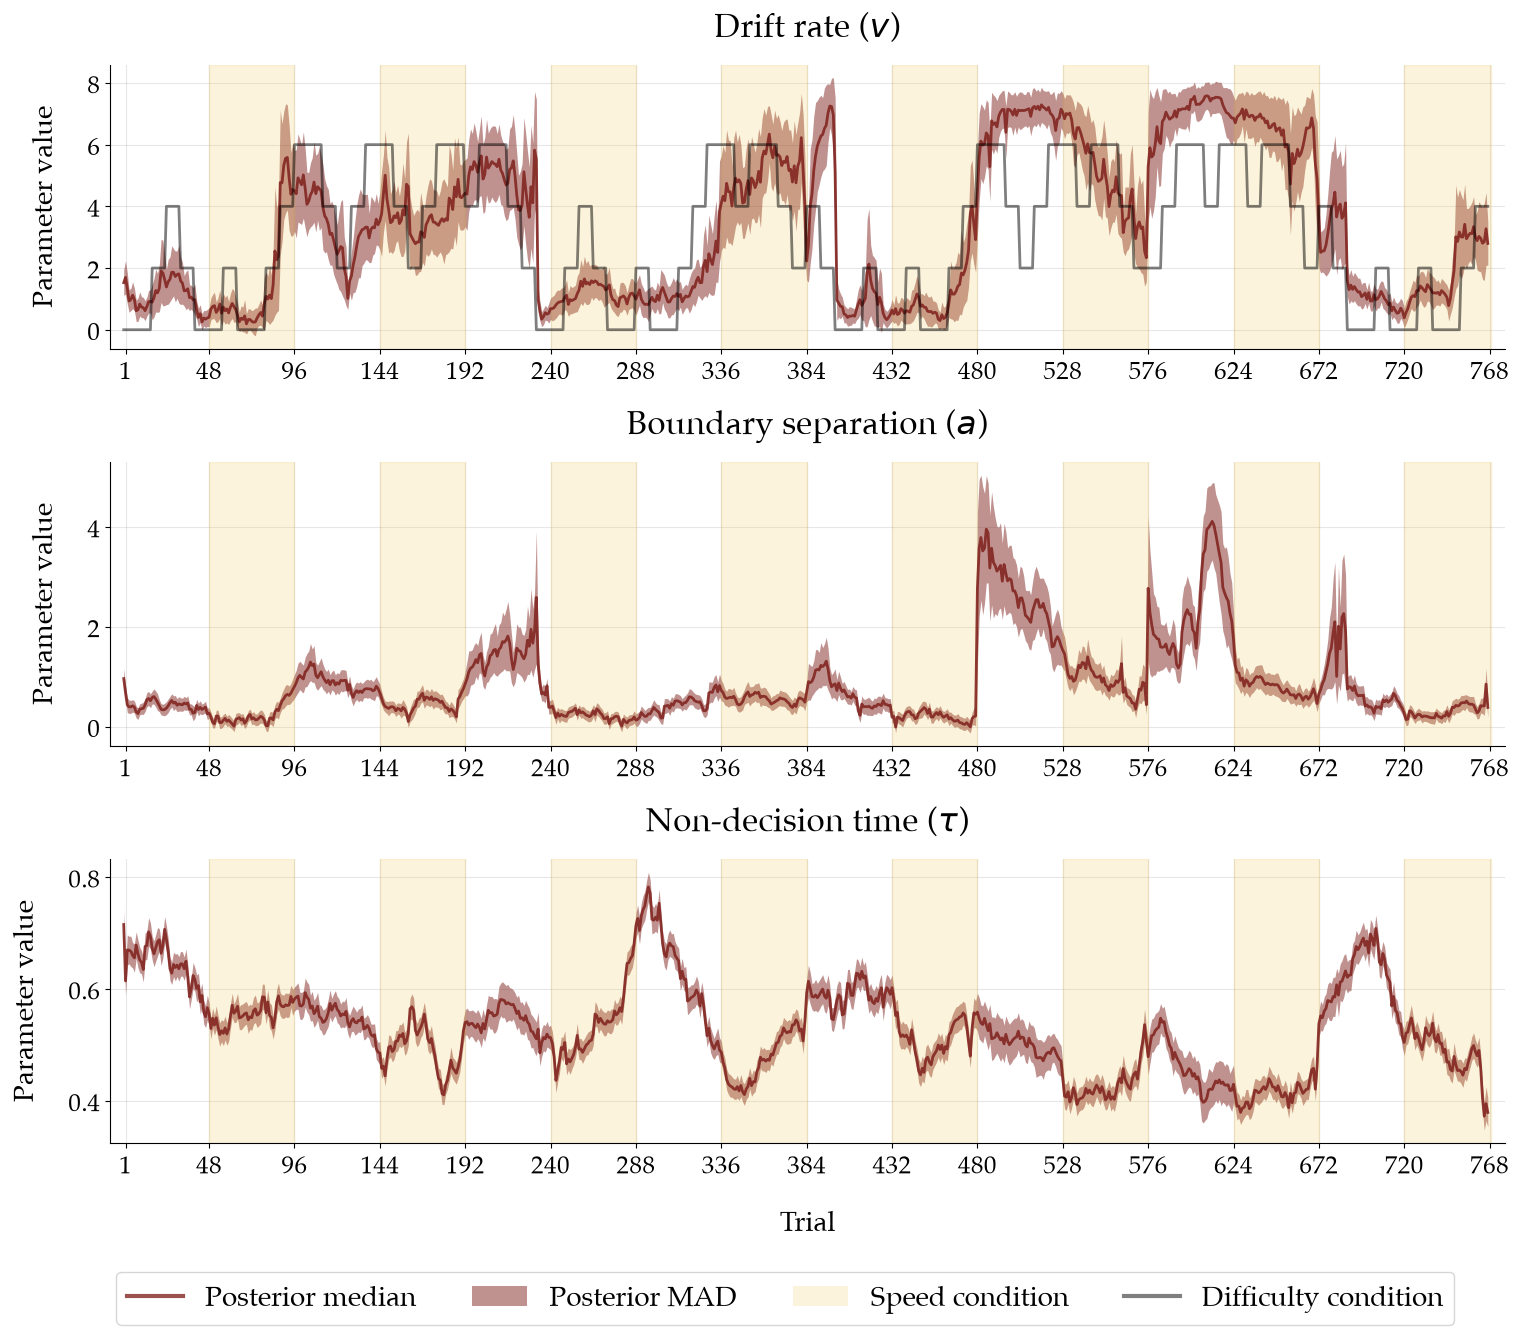

In [30]:
fig = plot_parameter_trajectory(
    post_summaries, context_data, dataset_idx=3, lw=2
)